# Khám phá dữ liệu (EDA) - AI4I 2020 Predictive Maintenance
Notebook này phân tích về dữ liệu dự đoán bảo trì, mất cân bằng lớp (Imbalance), các loại lỗi, mức độ tương quan và Outlier.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn project root để load các module trong src
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner

# Tạo thư mục outputs nếu chưa có
os.makedirs(os.path.join(project_root, 'outputs', 'figures'), exist_ok=True)
sns.set_theme(style="whitegrid")

In [2]:
# 1. Đọc và Tiền xử lý dữ liệu
loader = DataLoader(config_path='../configs/params.yaml')
df_raw = loader.load_data()

cleaner = DataCleaner(config_path='../configs/params.yaml')
df_cleaned = cleaner.run_pipeline(df_raw)

df_cleaned.head()

Loading data từ: ..\data\raw\ai4i2020.csv...
✅ Kiểm tra Schema thành công! Dữ liệu hợp lệ.
Bắt đầu Data Cleaning Pipeline...
[*] Không phát hiện giá trị bị thiếu (missing values).
[*] Đã loại bỏ các cột không cần thiết: ['UDI', 'Product ID']
  -> Đã binning cột 'Air temperature' thành 'Air temperature_binned' (Low, Medium, High)
  -> Đã binning cột 'Process temperature' thành 'Process temperature_binned' (Low, Medium, High)
  -> Đã binning cột 'Rotational speed' thành 'Rotational speed_binned' (Low, Medium, High)
  -> Đã binning cột 'Torque' thành 'Torque_binned' (Low, Medium, High)
  -> Đã binning cột 'Tool wear' thành 'Tool wear_binned' (Low, Medium, High)
✅ Hoàn thành quy trình làm sạch dữ liệu.


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature_binned,Process temperature_binned,Rotational speed_binned,Torque_binned,Tool wear_binned
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,Low,Low,Medium,Medium,Low
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,Low,Low,Low,High,Low
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,Low,Low,Medium,High,Low
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,Low,Low,Low,Medium,Low
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,Low,Low,Low,Medium,Low


## 1. Phân phối nhãn Machine failure (Mất cân bằng lớp)

C:\Users\Admin\AppData\Local\Temp\ipykernel_27412\4004449769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_cleaned, x='Machine failure', palette='Set2')


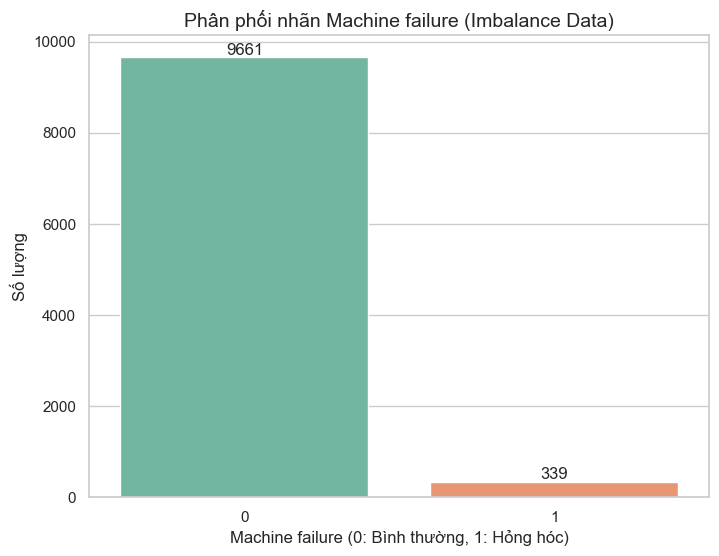

In [3]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_cleaned, x='Machine failure', palette='Set2')
plt.title('Phân phối nhãn Machine failure (Imbalance Data)', fontsize=14)
plt.xlabel('Machine failure (0: Bình thường, 1: Hỏng hóc)')
plt.ylabel('Số lượng')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

figure_path = os.path.join(project_root, 'outputs', 'figures', 'machine_failure_distribution.png')
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## 2. Số lượng các loại lỗi cụ thể (TWF, HDF, PWF, OSF, RNF)

C:\Users\Admin\AppData\Local\Temp\ipykernel_27412\1795317714.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Reds_r')


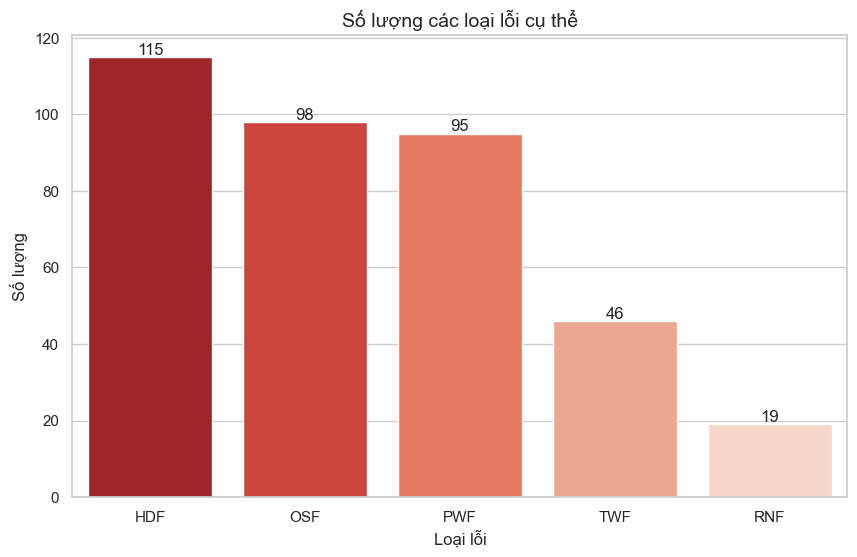

In [4]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df_cleaned[failure_types].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='Reds_r')
plt.title('Số lượng các loại lỗi cụ thể', fontsize=14)
plt.xlabel('Loại lỗi')
plt.ylabel('Số lượng')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

figure_path = os.path.join(project_root, 'outputs', 'figures', 'failure_types_count.png')
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## 3. Correlation Matrix (Heatmap) giữa các biến cảm biến

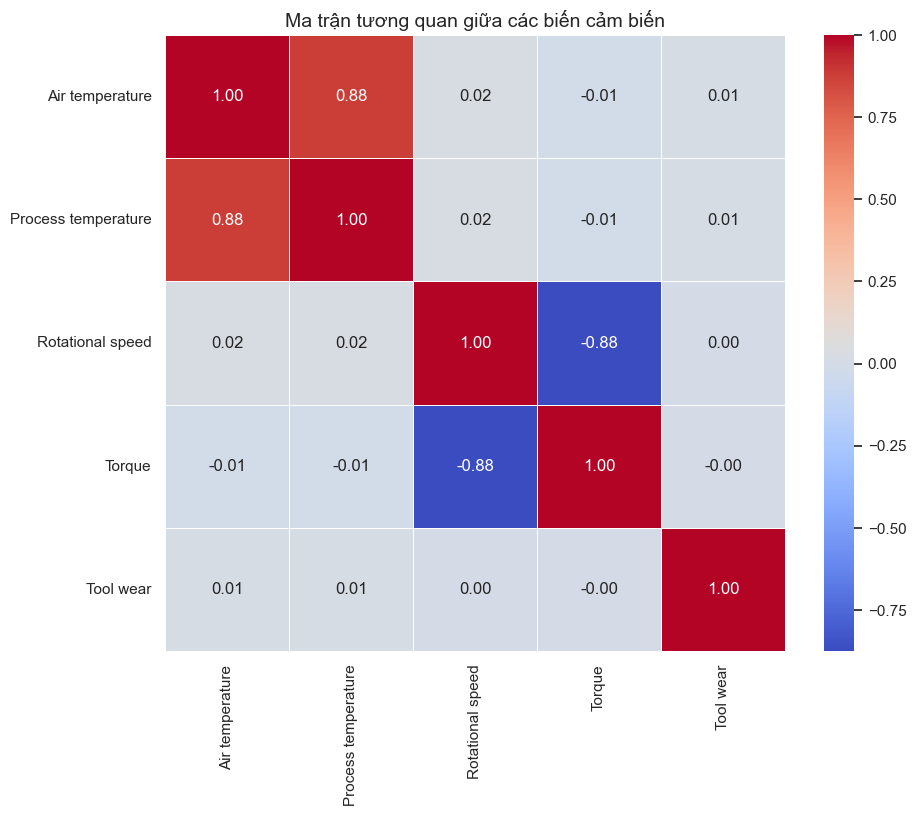

In [5]:
sensor_cols = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned[sensor_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến cảm biến', fontsize=14)

figure_path = os.path.join(project_root, 'outputs', 'figures', 'sensor_correlation_matrix.png')
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## 4. Phân tích Outlier cho 4 biến cảm biến

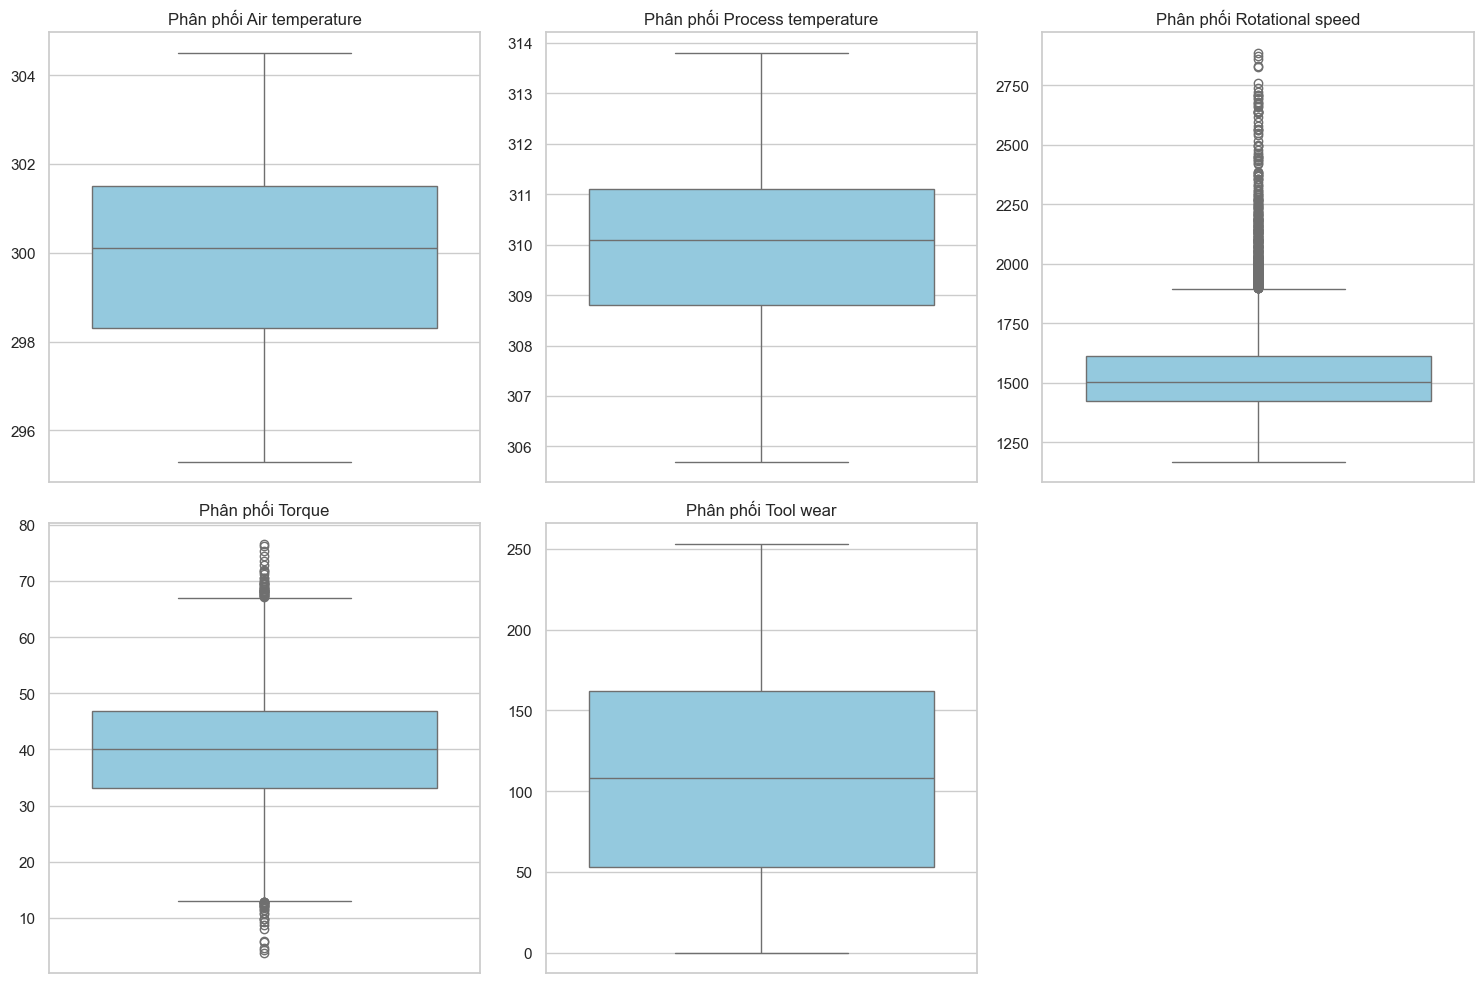

In [6]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(sensor_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_cleaned[col], color='skyblue')
    plt.title(f'Phân phối {col}', fontsize=12)
    plt.ylabel('')

plt.tight_layout()
figure_path = os.path.join(project_root, 'outputs', 'figures', 'sensor_outliers_boxplot.png')
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()